# Tech Challenge - Fase 1
## 02 - Modelagem

A partir da base processada na EDA (`wdbc_processed.csv`), treinamos e comparamos modelos de classificação para apoiar o diagnóstico de câncer de mama.

**Métrica prioritária:** *recall* da classe maligna (1). Em um contexto de triagem clínica, deixar de identificar um tumor maligno (falso negativo) é o erro mais custoso, então otimizamos para minimizá-lo.

## 1. Carga do dataset processado

In [2]:
import pandas as pd

In [3]:
df_processed = pd.read_csv("../data/processed/wdbc_processed.csv")

In [4]:
df_processed.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Separação entre features (X) e alvo (y)

In [5]:
X = df_processed.drop(columns=["diagnosis"])

In [6]:
y = df_processed["diagnosis"]

## 3. Divisão treino / teste estratificada

Usamos `stratify=y` para preservar a proporção das classes em ambos os conjuntos e `random_state=42` para reprodutibilidade.

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
# stratify=y preserva a proporção de classes em treino e teste;
# random_state fixa o resultado para garantir reprodutibilidade.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


Confirmando que a estratificação preservou a proporção de classes em treino e teste:

In [10]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


## 4. Padronização das features (StandardScaler)

O `StandardScaler` é ajustado **apenas no conjunto de treino** (`fit_transform`) e aplicado ao teste (`transform`). Isso evita *data leakage*: o conjunto de teste não influencia os parâmetros (média e desvio) da transformação.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [12]:
# fit_transform SOMENTE no treino: o scaler aprende média/desvio apenas com dados de treino.
# No teste usamos transform (mesmos parâmetros), evitando data leakage.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Sanidade: após a padronização, o conjunto de treino tem média ≈ 0 e desvio ≈ 1.

In [13]:
X_train_scaled.mean()

np.float64(1.6006731959430828e-17)

In [14]:
X_train_scaled.std()

np.float64(1.0)

## 5. Modelo 1 - Regressão Logística

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [16]:
y_pred[:20]

array([0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0])

Matriz de confusão (linhas = real, colunas = previsto):

In [17]:
from sklearn.metrics import confusion_matrix

# Linhas = valor real, colunas = previsto.
# A posição [1, 0] corresponde a um falso negativo - o erro mais crítico aqui.
matrix_confusion = confusion_matrix(y_test, y_pred)
print(matrix_confusion)

[[71  1]
 [ 3 39]]


Relatório de classificação completo:

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## 6. Modelo 2 - Árvore de Decisão (baseline comparativo)

Treinamos uma árvore de decisão como referência. Árvores são **invariantes à escala** das features, por isso usamos `X_train`/`X_test` originais (não padronizados).

In [19]:
from sklearn.tree import DecisionTreeClassifier

# Usa X sem padronização de propósito: árvores de decisão são invariantes à escala.
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [20]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [21]:
tree_matrix_confusion = confusion_matrix(y_test, y_pred_tree)
print(tree_matrix_confusion)

[[68  4]
 [ 4 38]]


## 7. Interpretação dos coeficientes (Regressão Logística)

Coeficientes ordenados por magnitude absoluta. Por estarem sobre features padronizadas, são diretamente comparáveis. Vale lembrar que o coeficiente reflete a **relevância condicional** da feature no modelo multivariado, que pode diferir da sua correlação marginal isolada vista na EDA.

In [22]:
# Coeficientes ordenados por magnitude absoluta.
# Como as features foram padronizadas, eles são diretamente comparáveis entre si.
coefficient = pd.Series(model.coef_[0], index=X.columns)
coefficient.sort_values(key=abs, ascending=False)

texture_worst              1.434093
radius_se                  1.233325
symmetry_worst             1.061264
concave points_mean        0.952813
concavity_worst            0.911406
area_se                    0.909029
compactness_se            -0.906925
area_worst                 0.900477
radius_worst               0.896968
concavity_mean             0.782298
perimeter_se               0.748295
perimeter_worst            0.723111
concave points_worst       0.703999
fractal_dimension_se      -0.593876
texture_mean               0.482219
concave points_se          0.482089
area_mean                  0.439950
compactness_mean          -0.439546
smoothness_worst           0.420207
texture_se                -0.407611
radius_mean                0.361150
perimeter_mean             0.353160
smoothness_mean            0.350622
symmetry_se               -0.330658
smoothness_se              0.247991
compactness_worst         -0.173488
symmetry_mean             -0.163991
concavity_se              -0

## 8. Interpretabilidade com SHAP

Além dos coeficientes da regressão logística, utilizamos o SHAP (SHapley Additive exPlanations) para interpretar o modelo. Enquanto os coeficientes oferecem uma visão global e linear, o SHAP explica a contribuição de cada feature para previsões individuais e permite validar, por um método independente, a importância das features identificada anteriormente.

In [23]:
import shap

# Cria o explainer para o modelo linear e calcula os valores SHAP no conjunto de teste
explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer(X_test_scaled)

Background dataset has 455 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=455 when initializing the masker.


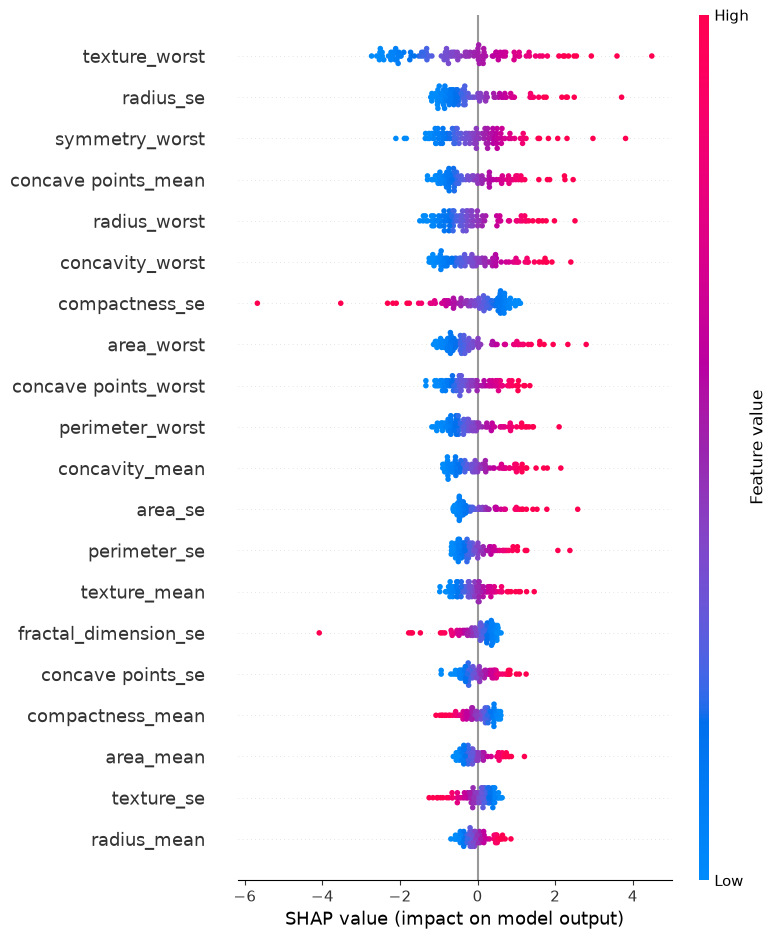

In [24]:
# Visão global: importância e direção do impacto de cada feature
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

## 9. Conclusão e discussão crítica

### Comparação dos modelos

| Modelo | Accuracy | Recall (maligno) | F1 (maligno) | Falsos negativos |
|---|---|---|---|---|
| **Regressão Logística** | 0,96 | **0,93** | **0,95** | **3** |
| Árvore de Decisão | 0,93 | 0,90 | 0,90 | 4 |

A **Regressão Logística supera a Árvore de Decisão em todas as métricas** e, o que é mais importante neste contexto, comete **menos falsos negativos** (3 vs. 4) - justamente o erro que mais queremos evitar. Somada à sua maior interpretabilidade (coeficientes + SHAP), ela é o **modelo escolhido**.

### Por que recall foi a métrica prioritária

Em triagem clínica os erros têm custos assimétricos: um **falso negativo** (deixar passar um tumor maligno) pode atrasar o tratamento e é o erro mais grave, enquanto um **falso positivo** gera exames adicionais, mas é corrigido na investigação seguinte. Por isso priorizamos o **recall da classe maligna**; e, como as classes são desbalanceadas, reportamos também *precision* e *F1* em vez de confiar na *accuracy* isolada.

### O modelo pode ser usado na prática? Como?

**Sim - mas exclusivamente como ferramenta de apoio à decisão, nunca como substituto do diagnóstico médico.**

O modelo se encaixa como uma camada de **triagem e priorização**: sinaliza os casos de maior risco para revisão prioritária, com o SHAP fornecendo, caso a caso, a justificativa da recomendação (evitando uma "caixa-preta").

**Limitações que impedem o uso autônomo:**

- **Falsos negativos ainda existem** (3 no teste) - sob supervisão médica, o(a) profissional atua como rede de segurança.
- **Dados de uma única fonte** (WDBC) - é necessária validação externa antes de qualquer implantação, pelo risco de *distribution shift*.
- **Validação preliminar** - os resultados vêm de um único *split*; validação cruzada e ajuste de limiar são passos seguintes.

**O(a) médico(a) sempre deve ter a palavra final no diagnóstico.** Este modelo apoia a triagem; não a substitui.